# 🫀 Pulse AI — Complete AI Backend Notebook
### Heart Disease Detection from Cardiac MRI (ACDC Dataset)
---
**Author:** Abdul Moiz | F22BDOCS1M01076  
**Dataset:** ACDC — Automated Cardiac Diagnosis Challenge (MICCAI 2017)  
**Model Output:** Low / Medium / High Threat Level  

---
## 📋 Notebook Flow
```
STEP 1  →  Install Libraries
STEP 2  →  Explore Dataset & Read Info.cfg Labels
STEP 3  →  Visualize Raw MRI Slices
STEP 4  →  Convert .nii.gz → PNG Images
STEP 5  →  Data Augmentation & Preprocessing
STEP 6  →  Build EfficientNetB0 Classification Model
STEP 7  →  Train the Model
STEP 8  →  Evaluate & Plot Results
STEP 9  →  Save Model for Flask API
STEP 10 →  Build Flask API (run separately)
```

---
## STEP 1 — Install Required Libraries

In [2]:
# Run this cell once to install all dependencies into the active notebook kernel
%pip install nibabel numpy matplotlib opencv-python scikit-learn tensorflow keras seaborn tqdm pillow

print("✅ All libraries installed successfully in the notebook kernel!")
print("ℹ️ If any package was newly installed, restart the kernel once before continuing.")

Note: you may need to restart the kernel to use updated packages.
✅ All libraries installed successfully in the notebook kernel!
ℹ️ If any package was newly installed, restart the kernel once before continuing.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ── Import All Libraries ──────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import nibabel as nib
import seaborn as sns
from tqdm import tqdm
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow Version : {tf.__version__}")
print(f"✅ NumPy Version      : {np.__version__}")
print(f"✅ All imports done!")

✅ TensorFlow Version : 2.20.0
✅ NumPy Version      : 2.4.2
✅ All imports done!


---
## STEP 2 — Configure Dataset Path & Explore Labels

In [ ]:
# ── CONFIGURE DATASET PATHS ───────────────────────────────────────
# Use BOTH training (100 patients) and testing (50 patients) = 150 total

DATASET_DIRS      = ['training', 'testing']  # Use ALL 150 patients
OUTPUT_PATH       = 'pulse_ai_dataset'       # PNG images will be saved here
MODEL_PATH        = 'pulse_ai_model.h5'      # Trained model save path
IMAGE_SIZE        = (224, 224)               # Input size for model
RANDOM_SEED       = 42
SLICES_PER_FRAME  = 4                        # Keep only the most informative slices per ED/ES frame
ROI_PADDING_RATIO = 0.18                     # Padding around the heart ROI crop
CENTER_CROP_RATIO = 0.70                     # Fallback crop used when no mask is available

# ── Label Mapping: ACDC 5 classes → Pulse AI 3 threat levels ─────
LABEL_MAP = {
    'NOR':  'Low',
    'ARV':  'Medium',
    'HCM':  'Medium',
    'MINF': 'High',
    'DCM':  'High'
}

# Numeric encoding for model
THREAT_TO_INT = {'Low': 0, 'Medium': 1, 'High': 2}
INT_TO_THREAT = {0: 'Low', 1: 'Medium', 2: 'High'}

print("✅ Configuration set!")
print(f"   Dataset Dirs        : {DATASET_DIRS}")
print(f"   Output Path         : {OUTPUT_PATH}")
print(f"   Image Size          : {IMAGE_SIZE}")
print(f"   Informative slices  : top {SLICES_PER_FRAME} per frame")
print(f"   ROI padding ratio   : {ROI_PADDING_RATIO}")
print(f"   Fallback crop ratio : {CENTER_CROP_RATIO}")
print(f"   Total patients expected: 150 (100 training + 50 testing)")
print()
print("📊 Label Mapping:")
for acdc, threat in LABEL_MAP.items():
    print(f"   {acdc:4s}  →  {threat}")

✅ Configuration set!
   Dataset Dirs : ['training', 'testing']
   Output Path  : pulse_ai_dataset
   Image Size   : (224, 224)
   Total patients expected: 150 (100 training + 50 testing)

📊 Label Mapping:
   NOR   →  Low
   ARV   →  Medium
   HCM   →  Medium
   MINF  →  High
   DCM   →  High


In [5]:
# ── Explore ALL Patients from training + testing folders ──────────
import os  # ensure available even if imports cell was skipped

def read_info(patient_folder):
    """Read Info.cfg and return a dict of patient metadata"""
    info_path = os.path.join(patient_folder, 'Info.cfg')
    info = {}
    with open(info_path, 'r') as f:
        for line in f:
            line = line.strip()
            if ': ' in line:
                key, value = line.split(': ', 1)
                info[key] = value
    return info

# Scan ALL patients from BOTH folders
patient_summary = []
label_counts    = {'NOR': 0, 'ARV': 0, 'HCM': 0, 'MINF': 0, 'DCM': 0}

for dataset_dir in DATASET_DIRS:
    if not os.path.isdir(dataset_dir):
        print(f"⚠ Directory not found: {dataset_dir}")
        continue
    for patient_id in sorted(os.listdir(dataset_dir)):
        patient_folder = os.path.join(dataset_dir, patient_id)
        if not os.path.isdir(patient_folder):
            continue
        try:
            info   = read_info(patient_folder)
            group  = info.get('Group', 'UNKNOWN')
            threat = LABEL_MAP.get(group, 'Unknown')
            ed     = info.get('ED', 'N/A')
            es     = info.get('ES', 'N/A')
            label_counts[group] = label_counts.get(group, 0) + 1
            patient_summary.append({
                'patient_id'  : patient_id,
                'source_dir'  : dataset_dir,
                'group'       : group,
                'threat'      : threat,
                'ed_frame'    : ed,
                'es_frame'    : es,
                'height'      : info.get('Height', 'N/A'),
                'weight'      : info.get('Weight', 'N/A')
            })
        except Exception as e:
            print(f"⚠ Could not read {patient_id}: {e}")

print(f"✅ Total patients found: {len(patient_summary)} (from {len(DATASET_DIRS)} folders)")
print()
print("📊 Class Distribution (ACDC labels):")
for label, count in label_counts.items():
    threat = LABEL_MAP.get(label, '?')
    bar    = '█' * count
    print(f"   {label:4s} ({threat:6s}): {bar} {count}")

# Threat level summary
threat_counts = {'Low': 0, 'Medium': 0, 'High': 0}
for p in patient_summary:
    threat_counts[p['threat']] = threat_counts.get(p['threat'], 0) + 1

print()
print("🎯 Pulse AI Threat Level Distribution:")
for t, c in threat_counts.items():
    bar = '█' * c
    print(f"   {t:6s}: {bar} {c}")

✅ Total patients found: 150 (from 2 folders)

📊 Class Distribution (ACDC labels):
   NOR  (Low   ): ██████████████████████████████ 30
   ARV  (Medium):  0
   HCM  (Medium): ██████████████████████████████ 30
   MINF (High  ): ██████████████████████████████ 30
   DCM  (High  ): ██████████████████████████████ 30
   RV   (?     ): ██████████████████████████████ 30

🎯 Pulse AI Threat Level Distribution:
   Low   : ██████████████████████████████ 30
   Medium: ██████████████████████████████ 30
   High  : ████████████████████████████████████████████████████████████ 60
   Unknown: ██████████████████████████████ 30


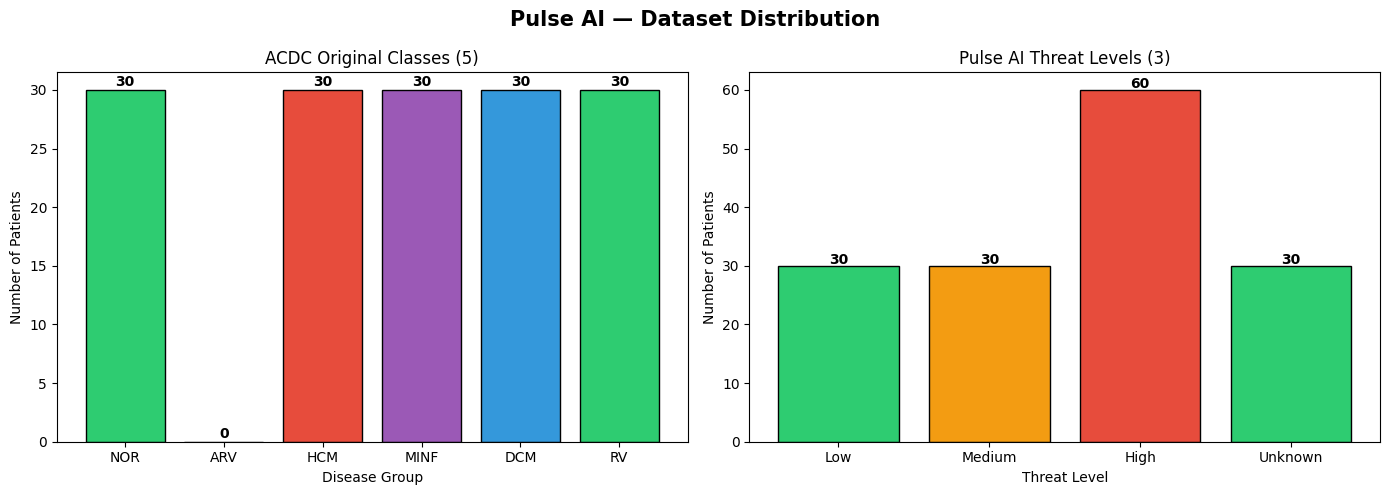

✅ Distribution plot saved!


In [6]:
# ── Plot Class Distribution ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pulse AI — Dataset Distribution', fontsize=15, fontweight='bold')

# Plot 1: ACDC 5 classes
colors1 = ['#2ecc71', '#f39c12', '#e74c3c', '#9b59b6', '#3498db']
axes[0].bar(label_counts.keys(), label_counts.values(), color=colors1, edgecolor='black')
axes[0].set_title('ACDC Original Classes (5)', fontsize=12)
axes[0].set_xlabel('Disease Group')
axes[0].set_ylabel('Number of Patients')
for i, (k, v) in enumerate(label_counts.items()):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Plot 2: Pulse AI 3 threat levels
colors2 = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(threat_counts.keys(), threat_counts.values(), color=colors2, edgecolor='black')
axes[1].set_title('Pulse AI Threat Levels (3)', fontsize=12)
axes[1].set_xlabel('Threat Level')
axes[1].set_ylabel('Number of Patients')
for i, (k, v) in enumerate(threat_counts.items()):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distribution plot saved!")

---
## STEP 3 — Visualize Raw MRI Slices

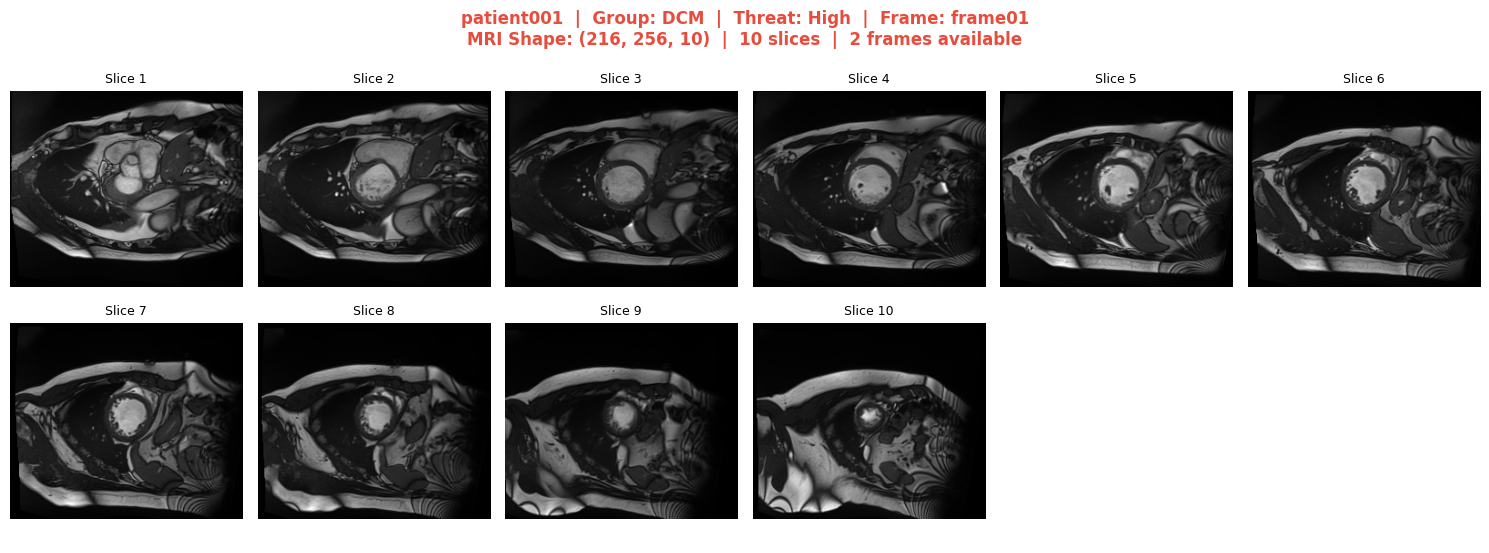

📋 Patient Info: Height=184.0cm, Weight=95.0kg
   Available frames: ['frame01', 'frame12']


In [7]:
# ── Visualize Slices for One Patient ─────────────────────────────
def load_mri_volume(patient_folder, patient_id):
    """Load MRI frames — returns list of (data, frame_name) tuples for ALL available frames"""
    volumes = []
    # Find all frame files (not _gt, not _4d)
    for fname in sorted(os.listdir(patient_folder)):
        if fname.endswith('.nii.gz') and '_frame' in fname and '_gt' not in fname and '_4d' not in fname:
            path = os.path.join(patient_folder, fname)
            img  = nib.load(path)
            data = img.get_fdata()
            # Extract frame name like 'frame01'
            frame = fname.replace(f'{patient_id}_', '').replace('.nii.gz', '')
            volumes.append((data, frame))
    return volumes

def visualize_patient_slices(patient_id, source_dir='training', show_mask=False):
    patient_folder = os.path.join(source_dir, patient_id)
    info  = read_info(patient_folder)
    group = info.get('Group', 'UNKNOWN')
    threat = LABEL_MAP.get(group, 'Unknown')
    
    volumes = load_mri_volume(patient_folder, patient_id)
    if not volumes:
        print(f"⚠ No MRI frame found for {patient_id}")
        return
    
    data, frame = volumes[0]  # Show first frame for visualization
    
    num_slices = data.shape[2]
    cols = min(num_slices, 6)
    rows = (num_slices + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
    
    threat_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    color = threat_colors.get(threat, 'gray')
    
    fig.suptitle(
        f'{patient_id}  |  Group: {group}  |  Threat: {threat}  |  Frame: {frame}\n'
        f'MRI Shape: {data.shape}  |  {num_slices} slices  |  {len(volumes)} frames available',
        fontsize=12, fontweight='bold', color=color
    )
    
    axes = np.array(axes).flatten()
    for i in range(len(axes)):
        if i < num_slices:
            axes[i].imshow(data[:, :, i], cmap='gray')
            axes[i].set_title(f'Slice {i+1}', fontsize=9)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f"📋 Patient Info: Height={info.get('Height')}cm, Weight={info.get('Weight')}kg")
    print(f"   Available frames: {[v[1] for v in volumes]}")

# ── Show first patient ────────────────────────────────────────────
first = patient_summary[0]
visualize_patient_slices(first['patient_id'], first['source_dir'])

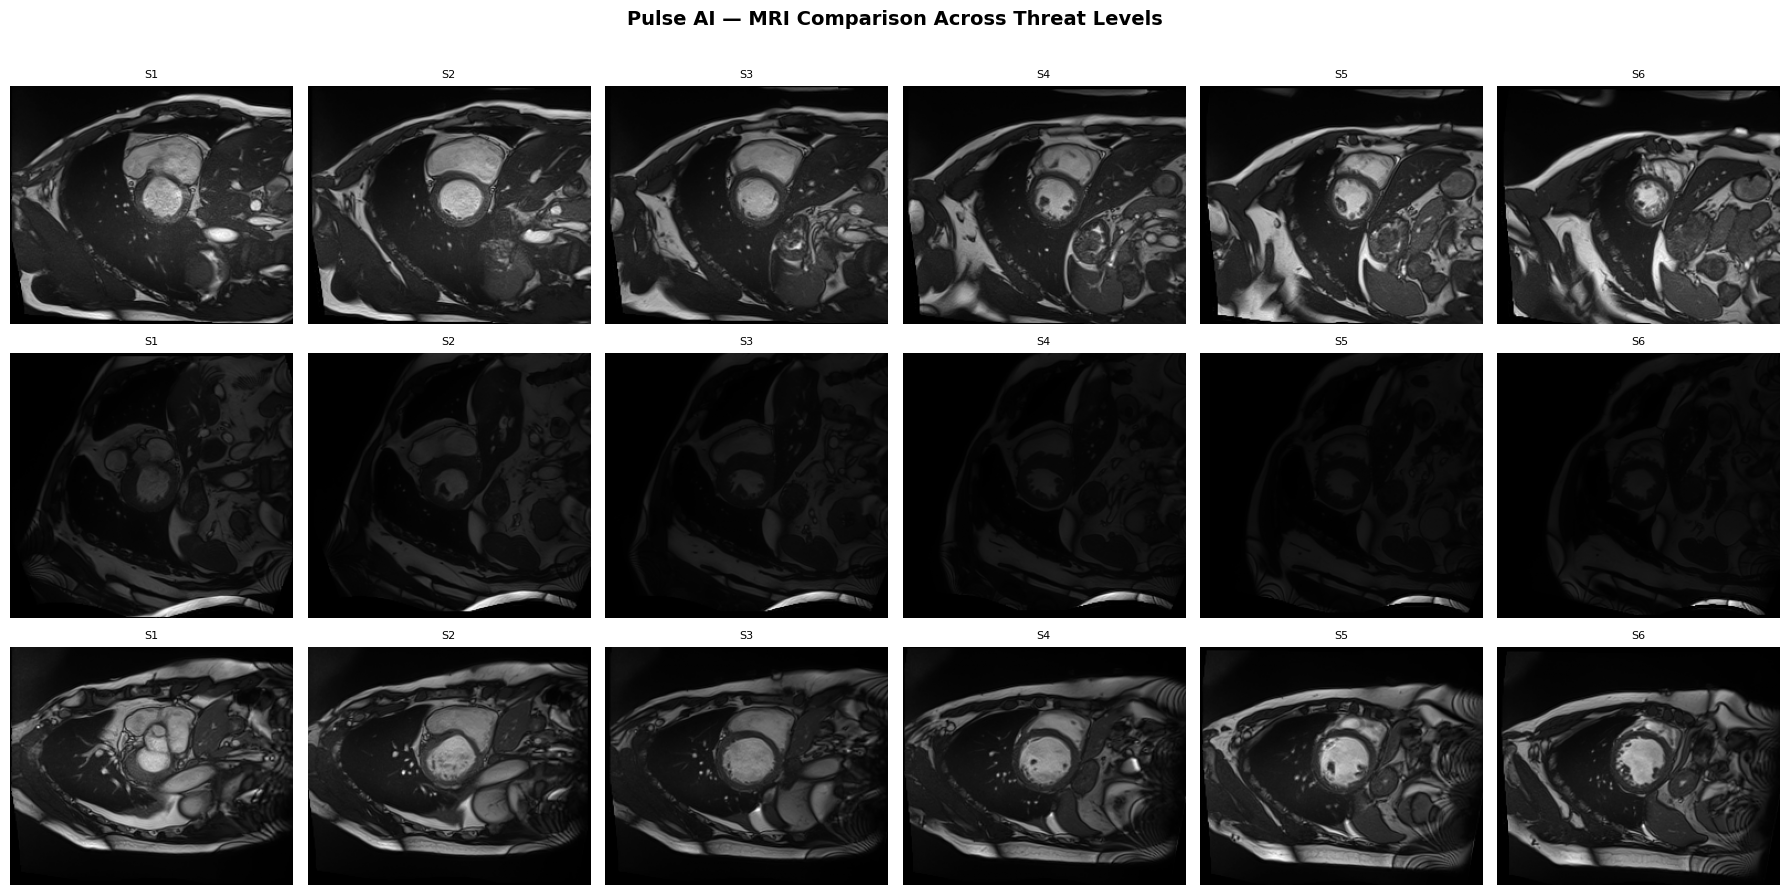

✅ MRI comparison saved!


In [8]:
# ── Compare One Patient from Each Threat Level ───────────────────
ACDC_TO_GROUP = {'Low': 'NOR', 'Medium': 'HCM', 'High': 'DCM'}

fig, big_axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Pulse AI — MRI Comparison Across Threat Levels', 
             fontsize=14, fontweight='bold', y=1.01)

row_idx = 0
for threat_level, acdc_group in [('Low (NOR)', 'NOR'), 
                                   ('Medium (HCM)', 'HCM'), 
                                   ('High (DCM)', 'DCM')]:
    sample_patient = next(
        (p for p in patient_summary if p['group'] == acdc_group), None
    )
    
    if sample_patient is None:
        continue
    
    pid    = sample_patient['patient_id']
    folder = os.path.join(sample_patient['source_dir'], pid)
    volumes = load_mri_volume(folder, pid)
    
    threat_colors = {'Low (NOR)': '#2ecc71', 'Medium (HCM)': '#f39c12', 'High (DCM)': '#e74c3c'}
    
    if volumes:
        data = volumes[0][0]
        num_slices = min(data.shape[2], 6)
        for col_idx in range(6):
            ax = big_axes[row_idx][col_idx]
            if col_idx < num_slices:
                ax.imshow(data[:, :, col_idx], cmap='gray')
                ax.set_title(f'S{col_idx+1}', fontsize=8)
            ax.axis('off')
            if col_idx == 0:
                ax.set_ylabel(threat_level, fontsize=10, fontweight='bold',
                              color=threat_colors[threat_level], rotation=90, labelpad=10)
                ax.yaxis.set_visible(True)
    row_idx += 1

plt.tight_layout()
plt.savefig('mri_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ MRI comparison saved!")

---
## STEP 4 — Convert .nii.gz → PNG Images (Full Dataset)

In [25]:
# ── Convert FULL ACDC Dataset to PNG (ROI-cropped, informative slices) ──
import shutil

# Notebook-safe defaults if this cell is re-run before the config cell.
SLICES_PER_FRAME = globals().get('SLICES_PER_FRAME', 4)
ROI_PADDING_RATIO = globals().get('ROI_PADDING_RATIO', 0.18)
CENTER_CROP_RATIO = globals().get('CENTER_CROP_RATIO', 0.70)


def normalize_slice(slice_2d):
    """Normalize a 2D MRI slice to 0-255 uint8"""
    min_val, max_val = slice_2d.min(), slice_2d.max()
    if max_val == min_val:
        return np.zeros(slice_2d.shape, dtype=np.uint8)
    normalized = (slice_2d - min_val) / (max_val - min_val)
    return (normalized * 255).astype(np.uint8)


def center_crop_slice(slice_2d, crop_ratio=0.70):
    """Fallback crop for inference-like behavior when a mask is unavailable."""
    height, width = slice_2d.shape
    crop_h = max(32, int(height * crop_ratio))
    crop_w = max(32, int(width * crop_ratio))
    y0 = max(0, (height - crop_h) // 2)
    x0 = max(0, (width - crop_w) // 2)
    y1 = min(height, y0 + crop_h)
    x1 = min(width, x0 + crop_w)
    return slice_2d[y0:y1, x0:x1]


def crop_to_heart_roi(slice_2d, mask_2d=None, padding_ratio=0.18, fallback_crop_ratio=0.70):
    """Crop around the heart mask; if no mask exists, fall back to a center crop."""
    if mask_2d is None or np.sum(mask_2d > 0) == 0:
        return center_crop_slice(slice_2d, crop_ratio=fallback_crop_ratio)

    coords = np.argwhere(mask_2d > 0)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0) + 1

    roi_h = max(1, y_max - y_min)
    roi_w = max(1, x_max - x_min)
    pad_y = max(6, int(roi_h * padding_ratio))
    pad_x = max(6, int(roi_w * padding_ratio))

    y0 = max(0, y_min - pad_y)
    y1 = min(slice_2d.shape[0], y_max + pad_y)
    x0 = max(0, x_min - pad_x)
    x1 = min(slice_2d.shape[1], x_max + pad_x)

    return slice_2d[y0:y1, x0:x1]


def load_frame_with_gt(patient_folder, patient_id, frame_num):
    """Load a specific frame and its ground truth mask"""
    frame_file = os.path.join(patient_folder, f'{patient_id}_frame{frame_num:02d}.nii.gz')
    gt_file = os.path.join(patient_folder, f'{patient_id}_frame{frame_num:02d}_gt.nii.gz')

    if not os.path.exists(frame_file):
        return None, None

    img = nib.load(frame_file)
    data = img.get_fdata()

    gt_data = None
    if os.path.exists(gt_file):
        gt_data = nib.load(gt_file).get_fdata()

    return data, gt_data


def get_informative_slice_indices(gt_data, num_slices, max_slices=4, min_heart_pixels=50):
    """Keep only the strongest heart slices to reduce label noise."""
    if gt_data is not None:
        scored_slices = []
        for slice_idx in range(num_slices):
            heart_pixels = int(np.sum(gt_data[:, :, slice_idx] > 0))
            if heart_pixels >= min_heart_pixels:
                scored_slices.append((slice_idx, heart_pixels))

        if scored_slices:
            top_slices = sorted(scored_slices, key=lambda item: item[1], reverse=True)[:max_slices]
            return sorted(top_slices, key=lambda item: item[0]), len(scored_slices)

    fallback_count = min(max_slices, num_slices)
    start_idx = max(0, (num_slices - fallback_count) // 2)
    fallback = [(slice_idx, 0) for slice_idx in range(start_idx, start_idx + fallback_count)]
    return fallback, len(fallback)


def convert_full_dataset_to_png(patient_list, output_root, img_size=(224, 224)):
    """
    Convert ALL patients to PNG using only the strongest slices per frame.
    - Uses ED + ES frames from Info.cfg
    - Ranks slices by GT heart area and keeps the top K slices
    - Crops the heart ROI with padding to suppress background noise
    - Applies CLAHE contrast enhancement for better local structure
    """
    if os.path.exists(output_root):
        shutil.rmtree(output_root)
    for threat in ['Low', 'Medium', 'High']:
        os.makedirs(os.path.join(output_root, threat), exist_ok=True)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    stats = {
        'processed': 0,
        'skipped': 0,
        'total_images': 0,
        'total_frames': 0,
        'candidate_slices': 0,
        'discarded_slices': 0,
        'Low': 0,
        'Medium': 0,
        'High': 0,
    }

    for patient in tqdm(patient_list, desc='Converting ALL patients'):
        pid = patient['patient_id']
        source_dir = patient['source_dir']
        threat = patient['threat']
        ed_frame = int(patient['ed_frame'])
        es_frame = int(patient['es_frame'])
        patient_folder = os.path.join(source_dir, pid)

        if threat == 'Unknown':
            stats['skipped'] += 1
            continue

        for frame_num in [ed_frame, es_frame]:
            data, gt_data = load_frame_with_gt(patient_folder, pid, frame_num)
            if data is None:
                continue

            stats['total_frames'] += 1
            num_slices = data.shape[2]
            selected_slices, candidate_count = get_informative_slice_indices(
                gt_data,
                num_slices,
                max_slices=SLICES_PER_FRAME,
                min_heart_pixels=50,
            )
            stats['candidate_slices'] += candidate_count
            stats['discarded_slices'] += max(0, candidate_count - len(selected_slices))

            for slice_idx, heart_pixels in selected_slices:
                mask_slice = gt_data[:, :, slice_idx] if gt_data is not None else None
                slice_2d = data[:, :, slice_idx]
                roi_slice = crop_to_heart_roi(
                    slice_2d,
                    mask_slice,
                    padding_ratio=ROI_PADDING_RATIO,
                    fallback_crop_ratio=CENTER_CROP_RATIO,
                )
                normalized = normalize_slice(roi_slice)
                enhanced = clahe.apply(normalized)
                resized = cv2.resize(enhanced, img_size, interpolation=cv2.INTER_CUBIC)
                rgb = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)

                filename = f'{pid}_frame{frame_num:02d}_slice{slice_idx:02d}_area{heart_pixels:05d}.png'
                out_path = os.path.join(output_root, threat, filename)
                cv2.imwrite(out_path, rgb)

                stats['total_images'] += 1
                stats[threat] += 1

        stats['processed'] += 1

    return stats


print("🔄 Starting ROI-focused dataset conversion...")
print(f"   Patients        : {len(patient_summary)} (training + testing)")
print(f"   Frames/patient  : 2 (ED + ES from Info.cfg)")
print(f"   Slice ranking   : top {SLICES_PER_FRAME} slices/frame by GT heart area")
print(f"   ROI crop        : heart bounding box + {ROI_PADDING_RATIO:.0%} padding")
print(f"   Fallback crop   : center {CENTER_CROP_RATIO:.0%} of the image")
print(f"   Enhancement     : CLAHE contrast boost")
print(f"   Output          : {OUTPUT_PATH}")
print()

stats = convert_full_dataset_to_png(patient_summary, OUTPUT_PATH, IMAGE_SIZE)

print()
print("✅ ROI-focused conversion complete!")
print(f"   Patients processed  : {stats['processed']}")
print(f"   Patients skipped    : {stats['skipped']}")
print(f"   Total frames used   : {stats['total_frames']}")
print(f"   Candidate slices    : {stats['candidate_slices']}")
print(f"   Discarded slices    : {stats['discarded_slices']}")
print(f"   Total PNG images    : {stats['total_images']}")
print()
print("📊 Images per threat level:")
print(f"   🟢 Low    : {stats['Low']} images")
print(f"   🟡 Medium : {stats['Medium']} images")
print(f"   🔴 High   : {stats['High']} images")

🔄 Starting ROI-focused dataset conversion...
   Patients        : 150 (training + testing)
   Frames/patient  : 2 (ED + ES from Info.cfg)
   Slice ranking   : top 4 slices/frame by GT heart area
   ROI crop        : heart bounding box + 18% padding
   Fallback crop   : center 70% of the image
   Enhancement     : CLAHE contrast boost
   Output          : pulse_ai_dataset



Converting ALL patients: 100%|██████████| 150/150 [00:29<00:00,  5.03it/s]


✅ ROI-focused conversion complete!
   Patients processed  : 120
   Patients skipped    : 30
   Total frames used   : 240
   Candidate slices    : 2128
   Discarded slices    : 1168
   Total PNG images    : 960

📊 Images per threat level:
   🟢 Low    : 240 images
   🟡 Medium : 240 images
   🔴 High   : 480 images


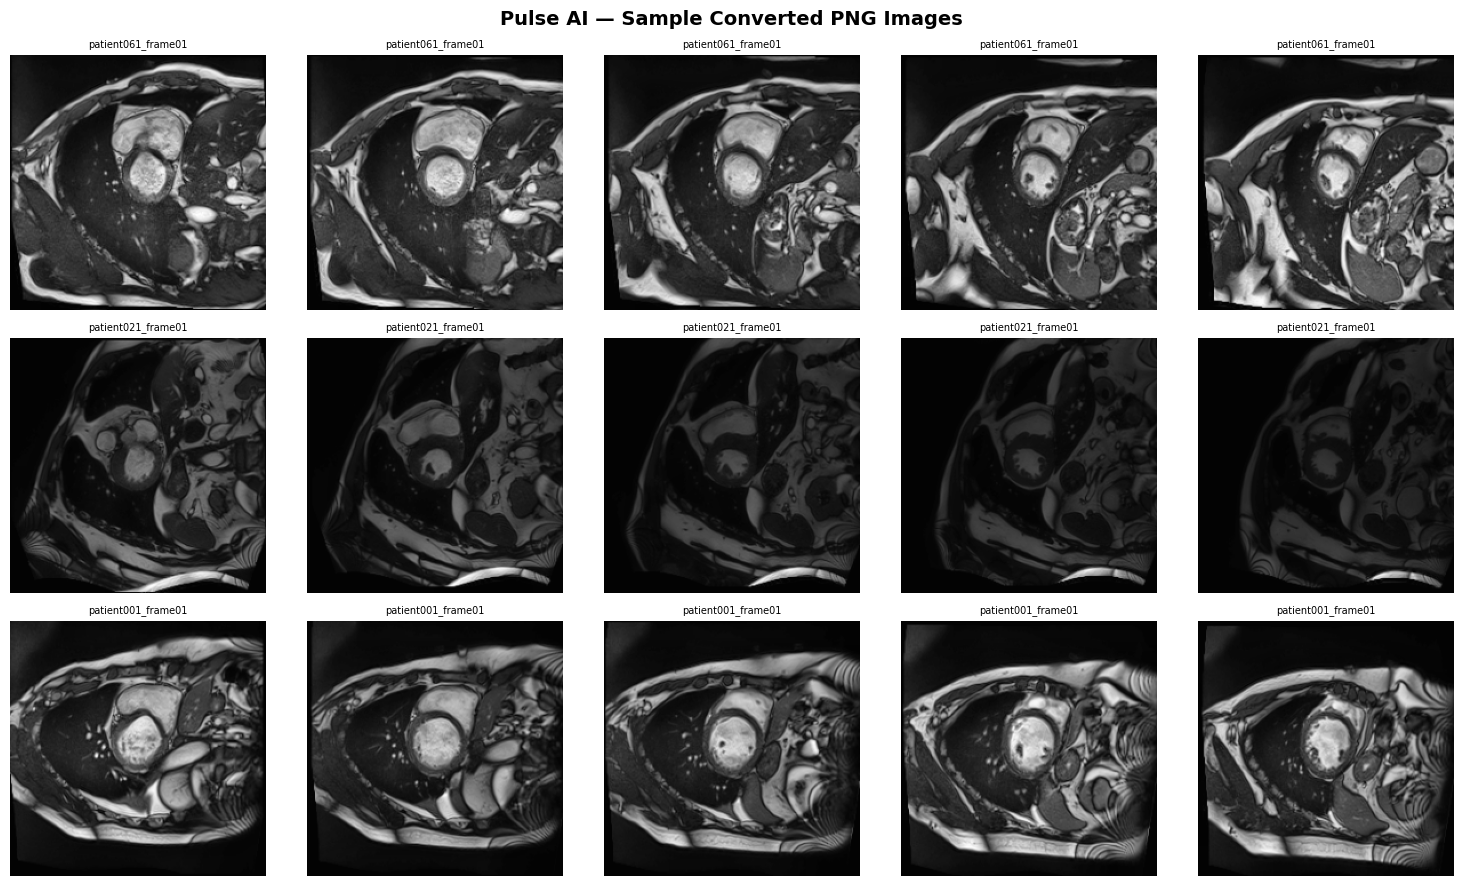

✅ PNG samples verified!


In [10]:
# ── Verify PNG Output — Show Sample Images ────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Pulse AI — Sample Converted PNG Images', 
             fontsize=14, fontweight='bold')

threat_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

for row, threat in enumerate(['Low', 'Medium', 'High']):
    folder  = os.path.join(OUTPUT_PATH, threat)
    images  = sorted(os.listdir(folder))[:5]
    
    for col, fname in enumerate(images):
        img = cv2.imread(os.path.join(folder, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].set_title(
            fname.split('_slice')[0], fontsize=7
        )
        axes[row][col].axis('off')
    
    axes[row][0].set_ylabel(
        f'⚠ {threat} Risk', fontsize=11, fontweight='bold',
        color=threat_colors[threat]
    )
    axes[row][0].yaxis.set_visible(True)

plt.tight_layout()
plt.savefig('sample_png_output.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PNG samples verified!")

---
## STEP 5 — Load Data & Preprocessing

In [26]:
# ── Load All PNG Images into Memory ──────────────────────────────
def extract_patient_id(filename):
    """Extract patient id from a PNG name like patient001_frame01_slice07.png"""
    return filename.split('_frame')[0]


def load_all_images(data_root, img_size=(224, 224)):
    X, y, patient_ids = [], [], []
    patient_label_map = {}

    for threat, label_int in THREAT_TO_INT.items():
        folder = os.path.join(data_root, threat)
        files = sorted(fname for fname in os.listdir(folder) if fname.endswith('.png'))

        for fname in tqdm(files, desc=f'Loading {threat}'):
            path = os.path.join(folder, fname)
            img = cv2.imread(path, cv2.IMREAD_COLOR)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size, interpolation=cv2.INTER_CUBIC)

            patient_id = extract_patient_id(fname)

            # Keep pixels in the native 0-255 range because EfficientNetB0
            # already contains a Rescaling layer at the model input.
            X.append(img.astype(np.float32))
            y.append(label_int)
            patient_ids.append(patient_id)
            patient_label_map[patient_id] = label_int

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    patient_ids = np.array(patient_ids)

    return X, y, patient_ids, patient_label_map


print("🔄 Loading images into memory...")
X, y, patient_ids, patient_label_map = load_all_images(OUTPUT_PATH, IMAGE_SIZE)

print(f"\n✅ Dataset loaded!")
print(f"   X shape           : {X.shape}")
print(f"   y shape           : {y.shape}")
print(f"   Unique patients   : {len(patient_label_map)}")
print(f"   Class distribution: Low={np.sum(y==0)}, Medium={np.sum(y==1)}, High={np.sum(y==2)}")
print(f"   Pixel range       : min={X.min():.1f}, max={X.max():.1f}")
print(f"   Input scale       : 0-255 (EfficientNet rescales internally)")
print(f"   Memory usage      : {X.nbytes / 1024**2:.1f} MB")

🔄 Loading images into memory...


Loading High: 100%|██████████| 480/480 [00:16<00:00, 28.31it/s]



✅ Dataset loaded!
   X shape           : (960, 224, 224, 3)
   y shape           : (960,)
   Unique patients   : 120
   Class distribution: Low=240, Medium=240, High=480
   Pixel range       : min=0.0, max=255.0
   Input scale       : 0-255 (EfficientNet rescales internally)
   Memory usage      : 551.2 MB


In [27]:
# ── Train / Validation / Test Split ──────────────────────────────
# 70% Train | 15% Validation | 15% Test
# Split by patient_id so slices from the same patient never leak across sets.

unique_patients = np.array(sorted(patient_label_map.keys()))
patient_labels = np.array([patient_label_map[pid] for pid in unique_patients])

train_patients, temp_patients, y_train_patients, y_temp_patients = train_test_split(
    unique_patients,
    patient_labels,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=patient_labels
)
val_patients, test_patients, y_val_patients, y_test_patients = train_test_split(
    temp_patients,
    y_temp_patients,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp_patients
)

train_mask = np.isin(patient_ids, train_patients)
val_mask = np.isin(patient_ids, val_patients)
test_mask = np.isin(patient_ids, test_patients)

train_patient_ids = patient_ids[train_mask]
val_patient_ids = patient_ids[val_mask]
test_patient_ids = patient_ids[test_mask]

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

train_val_overlap = set(train_patients) & set(val_patients)
train_test_overlap = set(train_patients) & set(test_patients)
val_test_overlap = set(val_patients) & set(test_patients)

print("✅ Patient-level split complete:")
print(f"   Train patients : {len(train_patients)}")
print(f"   Val patients   : {len(val_patients)}")
print(f"   Test patients  : {len(test_patients)}")
print(f"   Train images   : {X_train.shape[0]}")
print(f"   Validation imgs: {X_val.shape[0]}")
print(f"   Test images    : {X_test.shape[0]}")
print(f"   Leakage check  : {len(train_val_overlap) + len(train_test_overlap) + len(val_test_overlap)} shared patients")

# Compute class weights and patient-aware sample weights.
classes = np.unique(y_train)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weights = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_arr)}

train_unique_ids, train_slice_counts = np.unique(train_patient_ids, return_counts=True)
train_patient_slice_counts = {pid: int(count) for pid, count in zip(train_unique_ids, train_slice_counts)}
train_sample_weights = np.array([
    class_weights[int(label)] / train_patient_slice_counts[patient_id]
    for patient_id, label in zip(train_patient_ids, y_train)
], dtype=np.float32)
train_sample_weights *= len(train_sample_weights) / np.sum(train_sample_weights)

print(f"\n📊 Class Weights (patient-safe split): {class_weights}")
print(f"   Max train slices/patient : {max(train_patient_slice_counts.values())}")
print(f"   Mean sample weight       : {train_sample_weights.mean():.2f}")
print(f"   Weight range             : {train_sample_weights.min():.2f} → {train_sample_weights.max():.2f}")

✅ Patient-level split complete:
   Train patients : 84
   Val patients   : 18
   Test patients  : 18
   Train images   : 672
   Validation imgs: 144
   Test images    : 144
   Leakage check  : 0 shared patients

📊 Class Weights (patient-safe split): {0: 1.3333333333333333, 1: 1.3333333333333333, 2: 0.6666666666666666}
   Max train slices/patient : 8
   Mean sample weight       : 1.00
   Weight range             : 0.67 → 1.33


✅ Data augmentation pipeline ready!
   Batch size       : 16
   Steps per epoch  : 42
   Input scale      : raw 0-255 → model rescales internally
   Augmentation     : mild geometry + mild brightness
   Rebalancing      : inverse class frequency × inverse slices/patient


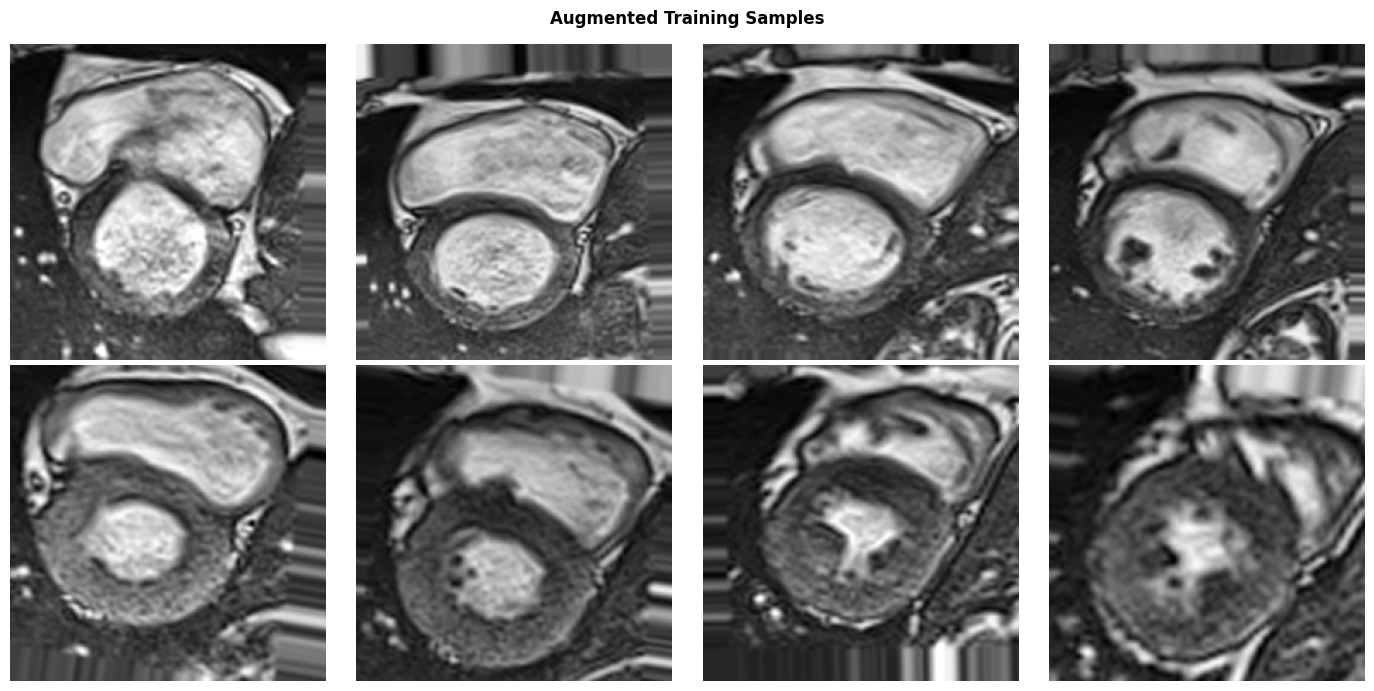

In [28]:
# ── Data Augmentation Pipeline ────────────────────────────────────
# EfficientNetB0 expects raw 0-255 images because the model contains a Rescaling layer.
# Augmentation stays anatomically conservative and sample weights balance patients/classes.


def to_display_image(image):
    image = np.asarray(image, dtype=np.float32)
    if image.max() <= 1.5:
        image = image * 255.0
    image = np.clip(image, 0, 255)
    return image.astype(np.uint8)


train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.06,
    height_shift_range=0.06,
    zoom_range=0.10,
    brightness_range=[0.92, 1.08],
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()  # No augmentation for validation

BATCH_SIZE = 16

train_gen = train_datagen.flow(
    X_train,
    y_train_cat,
    sample_weight=train_sample_weights,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_SEED,
)
val_gen = val_datagen.flow(
    X_val,
    y_val_cat,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("✅ Data augmentation pipeline ready!")
print(f"   Batch size       : {BATCH_SIZE}")
print(f"   Steps per epoch  : {len(train_gen)}")
print(f"   Input scale      : raw 0-255 → model rescales internally")
print(f"   Augmentation     : mild geometry + mild brightness")
print(f"   Rebalancing      : inverse class frequency × inverse slices/patient")

# Preview augmented samples without consuming the training generator state
preview_gen = train_datagen.flow(
    X_train[:8],
    y_train_cat[:8],
    batch_size=8,
    shuffle=False,
    seed=RANDOM_SEED,
)
sample_batch, _ = next(preview_gen)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Augmented Training Samples', fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    if i < len(sample_batch):
        ax.imshow(to_display_image(sample_batch[i]))
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## STEP 6 — Build EfficientNetB0 Classification Model

In [29]:
# ── Build Optimized Pulse AI Model ─────────────────────────────────
# EfficientNetB0 works best here when fed raw 0-255 RGB images.
# The model itself performs input rescaling, so do not divide X by 255 beforehand.

from tensorflow.keras.applications import EfficientNetB0


def build_pulse_ai_model(input_shape=(224, 224, 3), num_classes=3):
    """
    EfficientNetB0 + a stronger pooled head for ROI-focused cardiac MRI slices.
    Using both average and max pooling captures texture and shape cues better
    than a single pooled vector while keeping the head compact.
    """
    base_model = EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    features = base_model(inputs, training=False)
    pooled_avg = layers.GlobalAveragePooling2D(name='global_avg_pool')(features)
    pooled_max = layers.GlobalMaxPooling2D(name='global_max_pool')(features)
    x = layers.Concatenate(name='pooled_features')([pooled_avg, pooled_max])
    x = layers.BatchNormalization(name='pooled_bn')(x)
    x = layers.Dropout(0.30, name='dropout_1')(x)
    x = layers.Dense(
        256,
        activation='swish',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='dense_256'
    )(x)
    x = layers.BatchNormalization(name='dense_bn_1')(x)
    x = layers.Dropout(0.30, name='dropout_2')(x)
    x = layers.Dense(
        128,
        activation='swish',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='dense_128'
    )(x)
    x = layers.BatchNormalization(name='dense_bn_2')(x)
    x = layers.Dropout(0.20, name='dropout_3')(x)

    outputs = layers.Dense(
        num_classes,
        activation='softmax',
        name='threat_prediction'
    )(x)

    model = keras.Model(inputs, outputs, name='PulseAI_EfficientNetB0')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=2e-4),
        loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model, base_model


print("🔄 Building optimized model with EfficientNetB0...")
model, base_model = build_pulse_ai_model(input_shape=(*IMAGE_SIZE, 3))

print("\n🧠 Pulse AI Model Architecture:")
print(f"   Base model       : EfficientNetB0 (ImageNet pretrained)")
print(f"   Input shape      : {IMAGE_SIZE + (3,)}")
print(f"   Expected input   : raw 0-255 RGB")
print(f"   Label smoothing  : 0.02")
print(f"   Regularization   : L2(1e-4) + Dropout(0.30/0.30/0.20)")
print(f"   Head             : GAP + GMP → 256 → 128 → 3")
print()
model.summary()

🔄 Building optimized model with EfficientNetB0...

🧠 Pulse AI Model Architecture:
   Base model       : EfficientNetB0 (ImageNet pretrained)
   Input shape      : (224, 224, 3)
   Expected input   : raw 0-255 RGB
   Label smoothing  : 0.02
   Regularization   : L2(1e-4) + Dropout(0.30/0.30/0.20)
   Head             : GAP + GMP → 256 → 128 → 3



Model: "PulseAI_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_3[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_avg_pool     │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pool     │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooled_features     │ (None, 2560)      │          0 │ global_avg_pool[… │
│ (Concatenate)       │                   │            │ global_max_pool[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooled_bn           │ (None, 2560)      │     10,240 │ pooled_features[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2560)      │          0 │ pooled_bn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_256 (Dense)   │ (None, 256)       │    655,616 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_bn_1          │ (None, 256)       │      1,024 │ dense_256[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ dense_bn_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_bn_2          │ (None, 128)       │        512 │ dense_128[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ dense_bn_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ threat_prediction   │ (None, 3)         │        387 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,750,246 (18.12 MB)

 Trainable params: 694,787 (2.65 MB)

 Non-trainable params: 4,055,459 (15.47 MB)

---
## STEP 7 — Train the Model (Two Phases)

In [30]:
# ── PHASE 1: Train Custom Head (Base Frozen) ──────────────────────

callbacks_phase1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_phase1.h5',
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )
]

print("🚀 PHASE 1 Training — Custom Head Only (Base Frozen)")
print(f"   Epochs     : up to 25")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   LR         : 2e-4")
print(f"   Sampling   : patient-aware weighted batches")
print()

history1 = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

phase1_acc = max(history1.history['val_accuracy'])
print(f"\n✅ Phase 1 Complete! Best Val Accuracy: {phase1_acc:.4f} ({phase1_acc*100:.2f}%)")

🚀 PHASE 1 Training — Custom Head Only (Base Frozen)
   Epochs     : up to 25
   Batch size : 16
   LR         : 2e-4
   Sampling   : patient-aware weighted batches

Epoch 1/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.4098 - auc: 0.5643 - loss: 1.6204
Epoch 1: val_accuracy improved from None to 0.45833, saving model to best_phase1.h5



Epoch 1: finished saving model to best_phase1.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.4092 - auc: 0.5787 - loss: 1.5166 - val_accuracy: 0.4583 - val_auc: 0.5965 - val_loss: 1.3707 - learning_rate: 2.0000e-04
Epoch 2/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 685ms/step - accuracy: 0.4898 - auc: 0.6792 - loss: 1.2582
Epoch 2: val_accuracy improved from 0.45833 to 0.48611, saving model to best_phase1.h5



Epoch 2: finished saving model to best_phase1.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 35s 831ms/step - accuracy: 0.5015 - auc: 0.6934 - loss: 1.2287 - val_accuracy: 0.4861 - val_auc: 0.6996 - val_loss: 1.1344 - learning_rate: 2.0000e-04
Epoch 3/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 741ms/step - accuracy: 0.5716 - auc: 0.7523 - loss: 1.1728
Epoch 3: val_accuracy improved from 0.48611 to 0.55556, saving model to best_phase1.h5



Epoch 3: finished saving model to best_phase1.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 885ms/step - accuracy: 0.5655 - auc: 0.7539 - loss: 1.1248 - val_accuracy: 0.5556 - val_auc: 0.7435 - val_loss: 1.0219 - learning_rate: 2.0000e-04
Epoch 4/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 780ms/step - accuracy: 0.5778 - auc: 0.7832 - loss: 1.0026
Epoch 4: val_accuracy improved from 0.55556 to 0.61111, saving model to best_phase1.h5



Epoch 4: finished saving model to best_phase1.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 931ms/step - accuracy: 0.5476 - auc: 0.7744 - loss: 1.0407 - val_accuracy: 0.6111 - val_auc: 0.7911 - val_loss: 0.9441 - learning_rate: 2.0000e-04
Epoch 5/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.6505 - auc: 0.8244 - loss: 0.8988
Epoch 5: val_accuracy improved from 0.61111 to 0.67361, saving model to best_phase1.h5



Epoch 5: finished saving model to best_phase1.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 928ms/step - accuracy: 0.6622 - auc: 0.8351 - loss: 0.8873 - val_accuracy: 0.6736 - val_auc: 0.8199 - val_loss: 0.8904 - learning_rate: 2.0000e-04
Epoch 6/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 753ms/step - accuracy: 0.6597 - auc: 0.8434 - loss: 0.8987
Epoch 6: val_accuracy did not improve from 0.67361
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 876ms/step - accuracy: 0.6696 - auc: 0.8501 - loss: 0.8597 - val_accuracy: 0.6458 - val_auc: 0.8225 - val_loss: 0.9036 - learning_rate: 2.0000e-04
Epoch 7/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 719ms/step - accuracy: 0.7108 - auc: 0.8641 - loss: 0.8025
Epoch 7: val_accuracy improved from 0.67361 to 0.68056, saving model to best_phase1.h5



Epoch 7: finished saving model to best_phase1.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 865ms/step - accuracy: 0.7232 - auc: 0.8653 - loss: 0.8125 - val_accuracy: 0.6806 - val_auc: 0.8366 - val_loss: 0.8797 - learning_rate: 2.0000e-04
Epoch 8/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 783ms/step - accuracy: 0.7414 - auc: 0.8875 - loss: 0.7585
Epoch 8: val_accuracy improved from 0.68056 to 0.70833, saving model to best_phase1.h5



Epoch 8: finished saving model to best_phase1.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 936ms/step - accuracy: 0.7262 - auc: 0.8786 - loss: 0.7700 - val_accuracy: 0.7083 - val_auc: 0.8674 - val_loss: 0.8066 - learning_rate: 2.0000e-04
Epoch 9/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.7333 - auc: 0.8972 - loss: 0.7106
Epoch 9: val_accuracy improved from 0.70833 to 0.72917, saving model to best_phase1.h5



Epoch 9: finished saving model to best_phase1.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 934ms/step - accuracy: 0.7426 - auc: 0.8952 - loss: 0.7122 - val_accuracy: 0.7292 - val_auc: 0.8560 - val_loss: 0.8487 - learning_rate: 2.0000e-04
Epoch 10/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.7063 - auc: 0.8844 - loss: 0.7558
Epoch 10: val_accuracy improved from 0.72917 to 0.75000, saving model to best_phase1.h5



Epoch 10: finished saving model to best_phase1.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 39s 927ms/step - accuracy: 0.7068 - auc: 0.8792 - loss: 0.7850 - val_accuracy: 0.7500 - val_auc: 0.8739 - val_loss: 0.7972 - learning_rate: 2.0000e-04
Epoch 11/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.7840 - auc: 0.9209 - loss: 0.6344
Epoch 11: val_accuracy did not improve from 0.75000
42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 888ms/step - accuracy: 0.7634 - auc: 0.9159 - loss: 0.6409 - val_accuracy: 0.7153 - val_auc: 0.8662 - val_loss: 0.8255 - learning_rate: 2.0000e-04
Epoch 12/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.7476 - auc: 0.9149 - loss: 0.6176
Epoch 12: val_accuracy did not improve from 0.75000
42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 902ms/step - accuracy: 0.7530 - auc: 0.9063 - loss: 0.6822 - val_accuracy: 0.7361 - val_auc: 0.8674 - val_loss: 0.8264 - learning_rate: 2.0000e-04
Epoch 13/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.7505 - auc: 0.9149 - loss: 0.6564
Epoch 13

In [31]:
# ── PHASE 2: Fine-tune Top EfficientNet Layers ────────────────────
print("🔧 PHASE 2 — Fine-tuning EfficientNetB0")
print()

base_model.trainable = True
fine_tune_layers = 80

for layer in base_model.layers[:-fine_tune_layers]:
    layer.trainable = False

for layer in base_model.layers[-fine_tune_layers:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print(f"   Fine-tuned layers : last {fine_tune_layers}")
print(f"   Trainable layers  : {trainable_count}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-6),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        MODEL_PATH,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1
    )
]

print(f"\n🚀 PHASE 2 Training — Partial Fine-tuning")
print(f"   Epochs     : up to 25")
print(f"   LR         : 5e-6")
print(f"   Patience   : 10 epochs")
print(f"   Sampling   : patient-aware weighted batches")

history2 = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)

phase2_acc = max(history2.history['val_accuracy'])
print(f"\n✅ Phase 2 Complete! Best Val Accuracy: {phase2_acc:.4f} ({phase2_acc*100:.2f}%)")
print(f"   Model saved to: {MODEL_PATH}")

🔧 PHASE 2 — Fine-tuning EfficientNetB0

   Fine-tuned layers : last 80
   Trainable layers  : 63

🚀 PHASE 2 Training — Partial Fine-tuning
   Epochs     : up to 25
   LR         : 5e-6
   Patience   : 10 epochs
   Sampling   : patient-aware weighted batches


Epoch 1/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 854ms/step - accuracy: 0.7462 - auc: 0.9040 - loss: 0.6811
Epoch 1: val_accuracy improved from None to 0.75000, saving model to pulse_ai_model.h5



Epoch 1: finished saving model to pulse_ai_model.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 109s 1s/step - accuracy: 0.7262 - auc: 0.8913 - loss: 0.7243 - val_accuracy: 0.7500 - val_auc: 0.8757 - val_loss: 0.7936 - learning_rate: 5.0000e-06
Epoch 2/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 940ms/step - accuracy: 0.7217 - auc: 0.8857 - loss: 0.7567
Epoch 2: val_accuracy did not improve from 0.75000
42/42 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7426 - auc: 0.8998 - loss: 0.7031 - val_accuracy: 0.7361 - val_auc: 0.8744 - val_loss: 0.7995 - learning_rate: 5.0000e-06
Epoch 3/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7796 - auc: 0.9181 - loss: 0.6387
Epoch 3: val_accuracy did not improve from 0.75000
42/42 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.7634 - auc: 0.9072 - loss: 0.6810 - val_accuracy: 0.7361 - val_auc: 0.8775 - val_loss: 0.7894 - learning_rate: 5.0000e-06
Epoch 4/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7994 - auc: 0.9215 - loss: 0.6175
Epoch 4: val_accuracy imp


Epoch 4: finished saving model to pulse_ai_model.h5
42/42 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.7812 - auc: 0.9200 - loss: 0.6256 - val_accuracy: 0.7639 - val_auc: 0.8845 - val_loss: 0.7684 - learning_rate: 5.0000e-06
Epoch 5/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7428 - auc: 0.8908 - loss: 0.7182
Epoch 5: val_accuracy did not improve from 0.76389
42/42 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.7455 - auc: 0.8972 - loss: 0.7022 - val_accuracy: 0.7639 - val_auc: 0.8857 - val_loss: 0.7640 - learning_rate: 5.0000e-06
Epoch 6/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7066 - auc: 0.8749 - loss: 0.7585
Epoch 6: val_accuracy did not improve from 0.76389
42/42 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.7262 - auc: 0.8908 - loss: 0.7183 - val_accuracy: 0.7569 - val_auc: 0.8837 - val_loss: 0.7731 - learning_rate: 5.0000e-06
Epoch 7/25
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7921 - auc: 0.9288 - loss: 0.5819
Epoch 7: val_accuracy did not

---
## STEP 8 — Evaluate & Plot Training Results

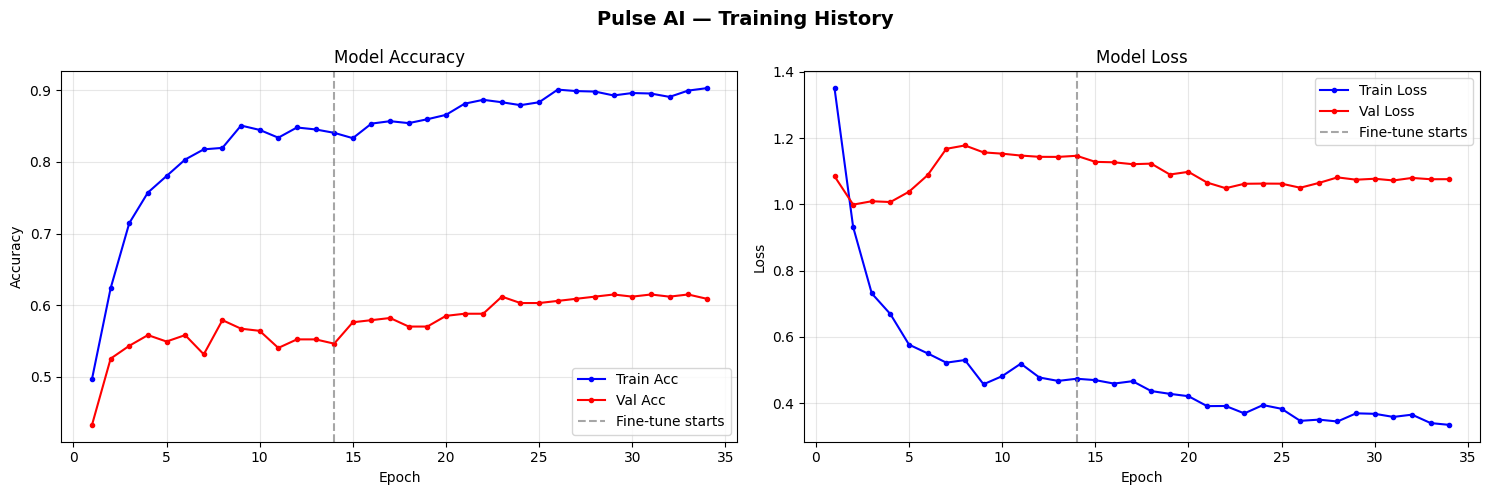

In [17]:
# ── Plot Training History ─────────────────────────────────────────
def merge_histories(h1, h2):
    """Merge Phase 1 and Phase 2 histories"""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged

history = merge_histories(history1, history2)
p1_end  = len(history1.history['loss'])  # Where Phase 1 ended

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Pulse AI — Training History', fontsize=14, fontweight='bold')

epochs = range(1, len(history['loss']) + 1)

# Accuracy plot
axes[0].plot(epochs, history['accuracy'], 'b-o', label='Train Acc', markersize=3)
axes[0].plot(epochs, history['val_accuracy'], 'r-o', label='Val Acc', markersize=3)
axes[0].axvline(x=p1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune starts')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(epochs, history['loss'], 'b-o', label='Train Loss', markersize=3)
axes[1].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', markersize=3)
axes[1].axvline(x=p1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune starts')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ── Final Evaluation on Test Set ──────────────────────────────────
print("📊 Evaluating on Test Set...\n")

# Load best saved model
best_model = keras.models.load_model(MODEL_PATH)

test_loss, test_acc, test_auc = best_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test AUC      : {test_auc:.4f}")

# Predictions
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Low Risk', 'Medium Risk', 'High Risk']
))

📊 Evaluating on Test Set...



   Test Loss     : 1.0375
   Test Accuracy : 0.6736 (67.36%)
   Test AUC      : 0.8162

📋 Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.59      0.72      0.65        40
 Medium Risk       0.75      0.19      0.30        32
   High Risk       0.71      0.86      0.78        72

    accuracy                           0.67       144
   macro avg       0.68      0.59      0.58       144
weighted avg       0.69      0.67      0.64       144



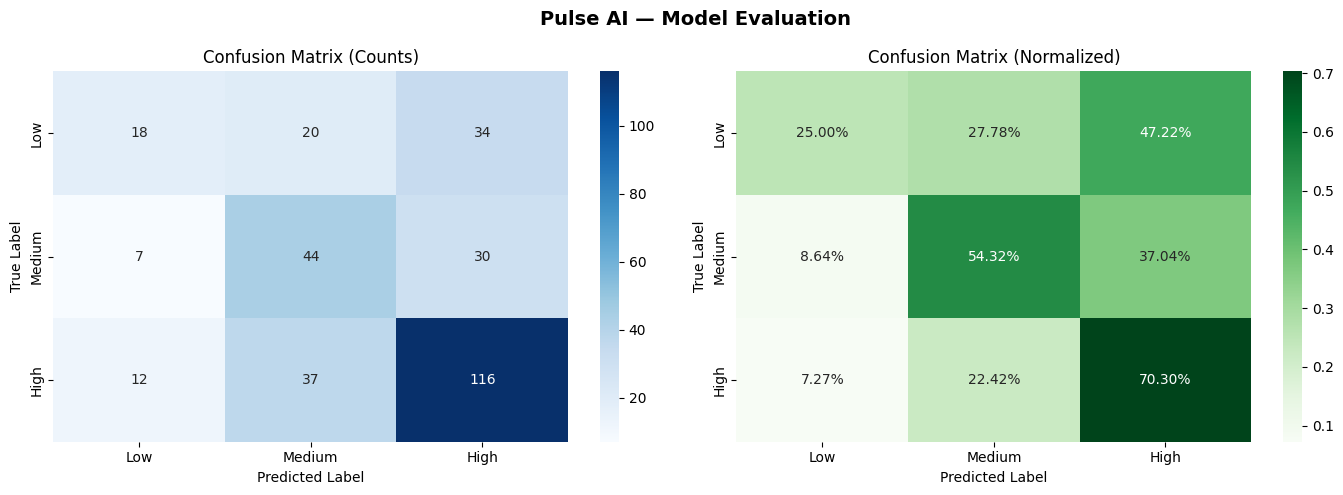


✅ Final Test Accuracy: 55.97%


In [19]:
# ── Confusion Matrix ──────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pulse AI — Model Evaluation', fontsize=14, fontweight='bold')

# Raw confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Final Test Accuracy: {test_acc*100:.2f}%")

🩺 Patient-Level Evaluation
   Test patients          : 18
   Patient-level Accuracy : 0.7778 (77.78%)

📋 Patient-Level Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.80      0.80      0.80         5
 Medium Risk       1.00      0.25      0.40         4
   High Risk       0.75      1.00      0.86         9

    accuracy                           0.78        18
   macro avg       0.85      0.68      0.69        18
weighted avg       0.82      0.78      0.74        18



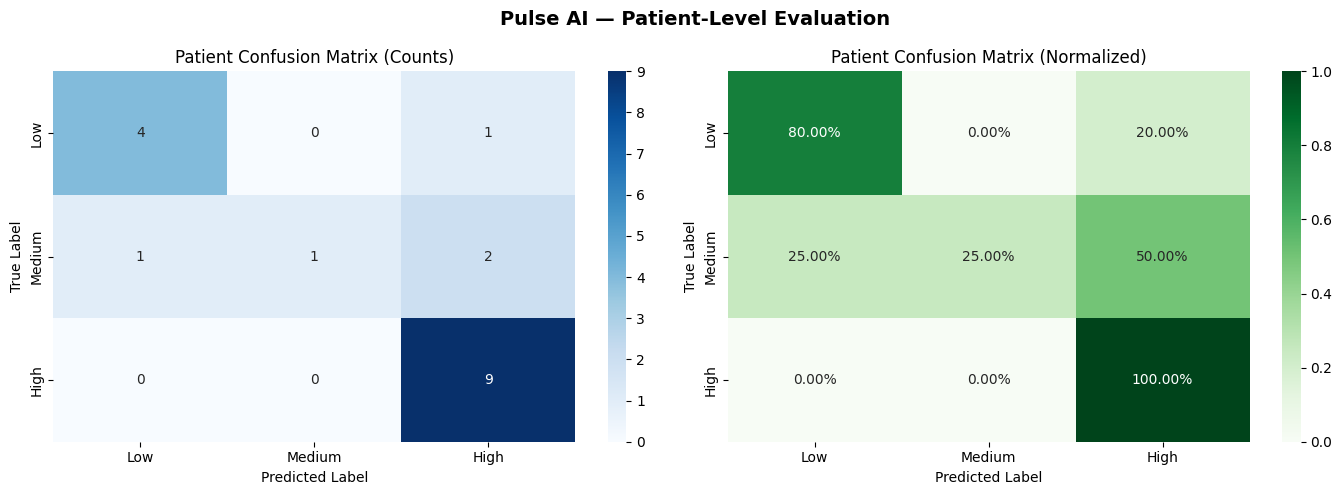

In [33]:
# ── Patient-Level Evaluation (Aggregate All Test Slices) ───────────
from collections import defaultdict

patient_test_ids = patient_ids[test_mask]
patient_prob_groups = defaultdict(list)
patient_true_labels = {}

for patient_id, probs, true_label in zip(patient_test_ids, y_pred_probs, y_test):
    patient_prob_groups[patient_id].append(probs)
    patient_true_labels[patient_id] = int(true_label)

patient_level_probs = []
patient_level_true = []
patient_level_pred = []

for patient_id in sorted(patient_prob_groups):
    avg_probs = np.mean(patient_prob_groups[patient_id], axis=0)
    pred_label = int(np.argmax(avg_probs))
    true_label = patient_true_labels[patient_id]

    patient_level_probs.append(avg_probs)
    patient_level_true.append(true_label)
    patient_level_pred.append(pred_label)

patient_level_probs = np.array(patient_level_probs)
patient_level_true = np.array(patient_level_true)
patient_level_pred = np.array(patient_level_pred)
patient_level_acc = np.mean(patient_level_pred == patient_level_true)

print("🩺 Patient-Level Evaluation")
print(f"   Test patients          : {len(patient_level_true)}")
print(f"   Patient-level Accuracy : {patient_level_acc:.4f} ({patient_level_acc*100:.2f}%)")
print()
print("📋 Patient-Level Classification Report:")
print(classification_report(
    patient_level_true,
    patient_level_pred,
    target_names=['Low Risk', 'Medium Risk', 'High Risk']
))

patient_cm = confusion_matrix(patient_level_true, patient_level_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pulse AI — Patient-Level Evaluation', fontsize=14, fontweight='bold')

sns.heatmap(patient_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title('Patient Confusion Matrix (Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

patient_cm_norm = patient_cm.astype('float') / patient_cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(patient_cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title('Patient Confusion Matrix (Normalized)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---
## STEP 9 — Save Model & Test Single Image Prediction

In [20]:
# ── Save in Multiple Formats ──────────────────────────────────────

# 1. Save as .h5 (Keras format — for Flask API)
best_model.save('pulse_ai_model.h5')
print("✅ Saved: pulse_ai_model.h5  (use with Flask)")

# 2. Convert to TFLite (for lightweight deployment)
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()
with open('pulse_ai_model.tflite', 'wb') as f:
    f.write(tflite_model)
print("✅ Saved: pulse_ai_model.tflite (lightweight version)")

print()
h5_size     = os.path.getsize('pulse_ai_model.h5') / 1024**2
tflite_size = os.path.getsize('pulse_ai_model.tflite') / 1024**2
print(f"📦 Model sizes:")
print(f"   .h5     : {h5_size:.1f} MB")
print(f"   .tflite : {tflite_size:.1f} MB")

✅ Saved: pulse_ai_model.h5  (use with Flask)
INFO:tensorflow:Assets written to: C:\Users\Abdul\AppData\Local\Temp\tmpsibxgc7y\assets


INFO:tensorflow:Assets written to: C:\Users\Abdul\AppData\Local\Temp\tmpsibxgc7y\assets


Saved artifact at 'C:\Users\Abdul\AppData\Local\Temp\tmpsibxgc7y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2902234022928: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2902234029840: TensorSpec(shape=(1, 1, 1, 3), dtype=tf.float32, name=None)
  2902234022736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2902234030416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2902234021968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2902234031760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2902234030032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2902234031184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2902219495696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2902219489744: TensorSpec(shape=(), dtype=tf.resource,

In [ ]:
# ── Test Single Image Prediction (Simulates Flask API Call) ───────
CENTER_CROP_RATIO = globals().get('CENTER_CROP_RATIO', 0.70)


def center_crop_rgb(image, crop_ratio=0.70):
    """Apply the same fallback crop used when a precise mask is unavailable."""
    height, width = image.shape[:2]
    crop_h = max(32, int(height * crop_ratio))
    crop_w = max(32, int(width * crop_ratio))
    y0 = max(0, (height - crop_h) // 2)
    x0 = max(0, (width - crop_w) // 2)
    y1 = min(height, y0 + crop_h)
    x1 = min(width, x0 + crop_w)
    return image[y0:y1, x0:x1]


def predict_single_image(img_path, model, img_size=(224, 224)):
    """
    Predict threat level for a single MRI PNG image.
    This approximates the training crop by center-cropping before resize.
    """
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = center_crop_rgb(img, crop_ratio=CENTER_CROP_RATIO)
    img = cv2.resize(img, img_size)
    img = img.astype(np.float32)
    img = np.expand_dims(img, axis=0)

    probs = model.predict(img, verbose=0)[0]

    result = {
        'threatLevel': INT_TO_THREAT[np.argmax(probs)],
        'confidence': round(float(np.max(probs)) * 100, 2),
        'probabilities': {
            'Low': round(float(probs[0]) * 100, 2),
            'Medium': round(float(probs[1]) * 100, 2),
            'High': round(float(probs[2]) * 100, 2)
        }
    }
    return result


print("🔬 Testing predictions on sample images:\n")
for threat in ['Low', 'Medium', 'High']:
    folder = os.path.join(OUTPUT_PATH, threat)
    sample = os.path.join(folder, os.listdir(folder)[0])
    result = predict_single_image(sample, best_model)

    emoji = {'Low': '🟢', 'Medium': '🟡', 'High': '🔴'}
    print(f"{emoji[threat]} True: {threat:6s}  →  Predicted: {result['threatLevel']:6s}  "
          f"(Confidence: {result['confidence']}%)")
    print(f"   Probabilities → Low: {result['probabilities']['Low']}%  "
          f"Medium: {result['probabilities']['Medium']}%  "
          f"High: {result['probabilities']['High']}%")
    print()

🔬 Testing predictions on sample images:

🟢 True: Low     →  Predicted: Medium  (Confidence: 98.74%)
   Probabilities → Low: 0.68%  Medium: 98.74%  High: 0.58%

🟡 True: Medium  →  Predicted: Medium  (Confidence: 97.38%)
   Probabilities → Low: 0.09%  Medium: 97.38%  High: 2.52%

🔴 True: High    →  Predicted: High    (Confidence: 93.61%)
   Probabilities → Low: 0.11%  Medium: 6.28%  High: 93.61%



---
## STEP 10 — Flask API Code
> ⚠ **Do NOT run this in the notebook.** Copy this code into a new file called `app.py` and run it separately with `python app.py`

In [ ]:
# ── app.py — Flask API for Pulse AI ──────────────────────────────
# Save this code in a file called app.py and run: python app.py

flask_code = '''
from flask import Flask, request, jsonify
from flask_cors import CORS
import numpy as np
import cv2
import tensorflow as tf

app = Flask(__name__)
CORS(app)  # Allow requests from Node.js backend

MODEL_PATH = "pulse_ai_model.h5"
model = tf.keras.models.load_model(MODEL_PATH)
INT_TO_THREAT = {0: "Low", 1: "Medium", 2: "High"}
IMAGE_SIZE = (224, 224)
CENTER_CROP_RATIO = 0.70

print(f"✅ Pulse AI Model loaded from {MODEL_PATH}")

def center_crop_rgb(image, crop_ratio=0.70):
    height, width = image.shape[:2]
    crop_h = max(32, int(height * crop_ratio))
    crop_w = max(32, int(width * crop_ratio))
    y0 = max(0, (height - crop_h) // 2)
    x0 = max(0, (width - crop_w) // 2)
    y1 = min(height, y0 + crop_h)
    x1 = min(width, x0 + crop_w)
    return image[y0:y1, x0:x1]

def preprocess_image(file_bytes):
    """Preprocess uploaded MRI image for model input"""
    img_array = np.frombuffer(file_bytes, np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = center_crop_rgb(img, crop_ratio=CENTER_CROP_RATIO)
    img = cv2.resize(img, IMAGE_SIZE)
    img = img.astype(np.float32)
    img = np.expand_dims(img, axis=0)
    return img

@app.route("/health", methods=["GET"])
def health_check():
    return jsonify({"status": "Pulse AI Flask API is running"})

@app.route("/analyze", methods=["POST"])
def analyze_mri():
    if "mri_image" not in request.files:
        return jsonify({"error": "No file uploaded"}), 400

    file = request.files["mri_image"]
    file_bytes = file.read()

    try:
        img = preprocess_image(file_bytes)
        probs = model.predict(img, verbose=0)[0]
        threat_idx = int(np.argmax(probs))
        threat_level = INT_TO_THREAT[threat_idx]
        confidence = round(float(np.max(probs)) * 100, 2)

        return jsonify({
            "threatLevel": threat_level,
            "confidence": confidence,
            "probabilities": {
                "Low": round(float(probs[0]) * 100, 2),
                "Medium": round(float(probs[1]) * 100, 2),
                "High": round(float(probs[2]) * 100, 2)
            },
            "recommendation": get_recommendation(threat_level)
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 500

def get_recommendation(threat_level):
    recommendations = {
        "Low": "No immediate concern. Routine annual checkup recommended.",
        "Medium": "Consult a cardiologist within 2-4 weeks for further evaluation.",
        "High": "Urgent cardiologist consultation required. Schedule within 48-72 hours."
    }
    return recommendations.get(threat_level, "Please consult a doctor.")

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''

with open('app.py', 'w') as f:
    f.write(flask_code.strip())

print("✅ app.py created!")
print()
print("To run the Flask API:")
print("  pip install flask flask-cors")
print("  python app.py")
print()
print("API Endpoints:")
print("  GET  http://localhost:5000/health")
print("  POST http://localhost:5000/analyze   ← send MRI image here")

UnicodeEncodeError: 'charmap' codec can't encode characters in position 219-220: character maps to <undefined>

In [ ]:
# ── Node.js Integration Code (Save as analyzeService.js) ─────────
nodejs_code = '''
// analyzeService.js — Call Pulse AI Flask from Node.js/Express
const axios   = require('axios');
const FormData = require('form-data');

const FLASK_URL = process.env.FLASK_URL || 'http://localhost:5000';

async function analyzeMRI(fileBuffer, originalFilename) {
    const formData = new FormData();
    formData.append('mri_image', fileBuffer, {
        filename    : originalFilename,
        contentType : 'image/png'
    });

    const response = await axios.post(`${FLASK_URL}/analyze`, formData, {
        headers : formData.getHeaders(),
        timeout : 30000  // 30 second timeout
    });

    return response.data;
    /*
    Returns:
    {
        threatLevel     : "High",
        confidence      : 87.45,
        probabilities   : { Low: 5.2, Medium: 7.35, High: 87.45 },
        recommendation  : "Urgent cardiologist consultation required..."
    }
    */
}

// Express route example
// router.post('/upload-mri', upload.single('mri'), async (req, res) => {
//     const result = await analyzeMRI(req.file.buffer, req.file.originalname);
//     await supabase.from('diagnoses').insert({ ...result, patientId: req.user.id });
//     res.json(result);
// });

module.exports = { analyzeMRI };
'''

with open('analyzeService.js', 'w') as f:
    f.write(nodejs_code.strip())

print("✅ analyzeService.js created!")
print("   Copy this file to your Node.js backend folder.")

---
## ✅ Summary — What You Now Have

| File | Purpose |
|---|---|
| `pulse_ai_model.h5` | Trained model for Flask API |
| `pulse_ai_model.tflite` | Lightweight model for deployment |
| `app.py` | Flask REST API — run with `python app.py` |
| `analyzeService.js` | Node.js service to call Flask |
| `pulse_ai_dataset/` | Converted PNG training images |
| `confusion_matrix.png` | Model evaluation chart |
| `training_history.png` | Training curves |

---

## 🏗️ Full System Flow
```
Patient uploads MRI (React)
        ↓
Node.js/Express backend receives file
        ↓
analyzeService.js → POST to Flask
        ↓
Flask preprocess → EfficientNetB0 model
        ↓
Returns { threatLevel, confidence, probabilities }
        ↓
Node.js saves result to Supabase DB
        ↓
Patient sees result on dashboard
```

---
**Author:** Abdul Moiz | F22BDOCS1M01076 | Pulse AI FYP